In [1]:
%matplotlib inline
import librosa
import numpy as np

from IPython import display
from matplotlib import pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

### 1. 先加载音频

In [3]:
filepath = "../../../data/audio/test/001.wav"
data, sampling_rate = librosa.load(filepath, sr=None, mono=True)
data.shape, sampling_rate

((39411,), 4800)

### 2. 频谱图

音频可视化处理画出其波形图，还可绘制其信号的频谱（spectrum），也称为信号的频域（frequency domain）表示。    
频谱可以通过离散傅里叶变换（Discrete Fourier Transform, DFT）求得，它描述了音频信号中每个频率成分的强度。 

我们可以使用`numpy`的`rfft()`函数来绘制加载音频数组(np.ndarray）的频谱图。

我们只取前面2秒数据的采样点来计算DFT。

In [4]:
dft_array = data[:sampling_rate * 2]
dft_array.shape

(9600,)

In [5]:
# 计算DFT
window = np.hanning(len(dft_array))
windowed_input = dft_array * window

dft = np.fft.rfft(windowed_input)

In [6]:
type(window), type(windowed_input), type(dft)

(numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [7]:
window.shape, windowed_input.shape, dft.shape

((9600,), (9600,), (4801,))

In [8]:
# 计算频谱的幅值，转换为分贝标度
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

amplitude_db.shape

(4801,)

In [9]:
# 计算每个DFT分量对应的频率值
frequency = librosa.fft_frequencies(sr=sampling_rate, n_fft=len(dft_array))
frequency.shape

(4801,)

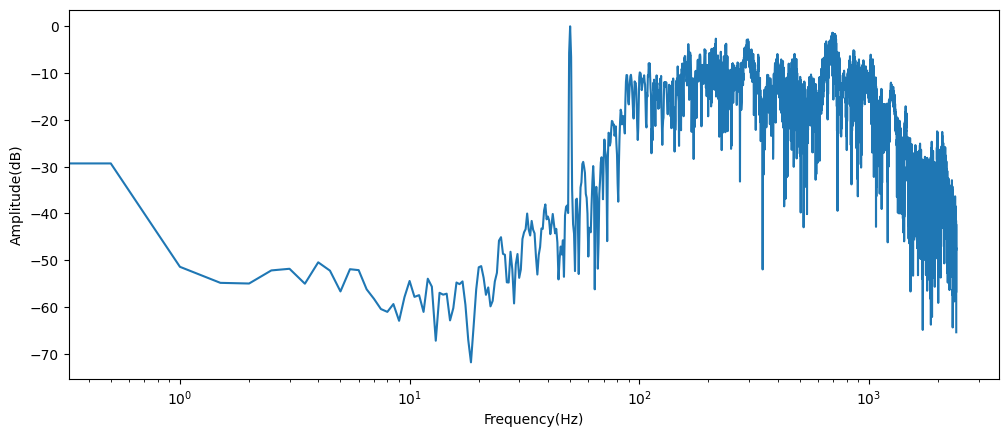

In [10]:
# 画图
# plt.figure().set_figheight(2)
plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency(Hz)")
plt.ylabel("Amplitude(dB)")
plt.xscale("log")

> 这张图向我们展示了截取的音频片段中每个频率成分的强度。
> 图中的x轴是频率的值，一般采用对数表示，y轴则对于频率的幅值。

### 3. 时频谱

我们能否用某种方法表示出频率成分随着时间的变化呢？

频谱的问题在于其智能表示一个短暂时间段内各个频率成分的总体幅值。这里的解决方法是我们可以进行多次的DFT，每次DFT都覆盖一小段不同的时间段，然后再把所有的频谱堆叠起来，这样就构成了时频谱（spectrogram）。

时频谱表示了音频信号中各个频率成分随时间变化的过程。    
它可以让你在一张图中看到时间、频率和幅值的所有信息。

**时频谱是信息量最大的音频工具之一。**

In [11]:
D = librosa.stft(data)
D.shape

(1025, 77)

In [12]:
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db.shape

(1025, 77)

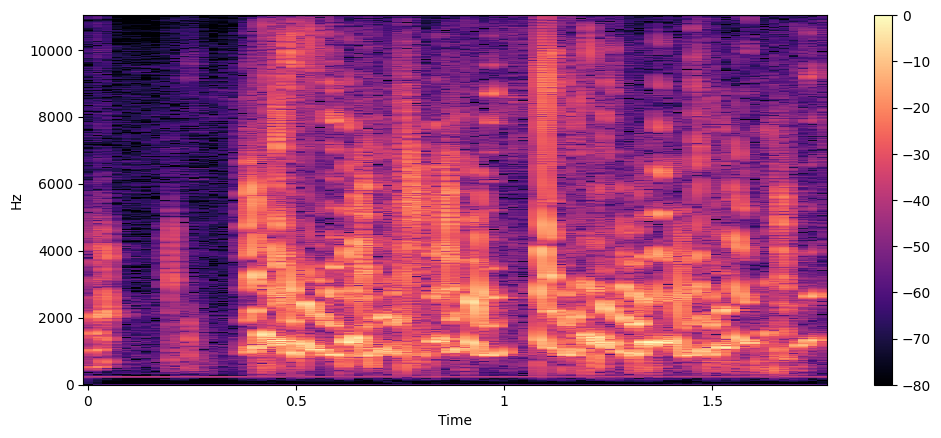

In [13]:
plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()
plt.show()

该图中：
- `x`轴表示的是和波形图中相同的时间
- `y`轴现在表示着不同的频率，以赫兹为单位。
- 颜色的强度表示着当前时间点和频率饿幅值强度，使用分贝(dB)标度。

### 4. 梅尔时频谱

梅尔时频谱（简称梅尔谱）是一种在语音处理和机器学习中常用的时频谱变体。     

梅尔谱也和时频谱一样表示频率成分随时间的变化，只是频率所在的轴不同。

In [14]:
S = librosa.feature.melspectrogram(y=data, sr=sampling_rate, n_mels=80, fmax=8000)
# n_mels表示梅尔滤波器组中的滤波器个数

S_dB = librosa.power_to_db(S, ref=np.max)

S_dB.shape

(80, 77)

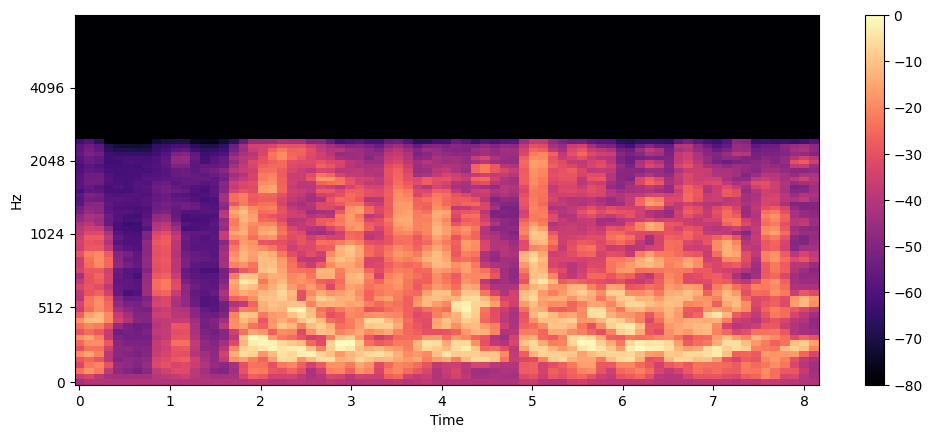

In [15]:
plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sampling_rate, fmax=8000)
plt.colorbar()
plt.show()